In [10]:
%reload_ext autoreload
%autoreload 2
from fun import *
from trade_fun import *
import polars as pl
import pandas as pd
import datetime as dt
import time 

logging = get_logger(log_file='双均线策略回测.log',inherit=False)

# 双均线策略回测

策略说明：
- 短期均线：SMA5
- 长期均线：SMA20
- 买入信号：SMA5 上穿 SMA20（金叉），收盘价买入
- 卖出信号：
  1. SMA5 下穿 SMA20（死叉）
  2. 止损：亏损 8%
  3. 追踪止损：从最高点回撤 5%
  4. 强制卖出：持仓超过 30 天
- 过滤条件：市值、成交量、ST过滤等

In [11]:
# ==================== 参数配置 ====================
start_date = dt.date(2025,1,1)
end_date = dt.datetime.today()

# 均线参数
short_window = 5   # 短期均线周期
long_window = 20   # 长期均线周期

# 过滤条件参数
params_dict = {
    'mv_min': 300,           # 最小自由流通市值（亿）
    'mv_max': 5000,         # 最大自由流通市值（亿）
    'vol_ratio_min': 0.8,   # 最小成交量比率（相对于20日均量）
    'price_position_max': 3, # 最大价格位置（当前价/60日最低价）
    'stop_loss_pct': 0.08,  # 止损比例（8%）
    'trailing_stop_pct': 0.05,  # 追踪止损比例（5%）
    'max_holding_days': 30,  # 最长持仓天数（30天）
}

logging.info(f"策略参数: {params_dict}")

策略参数: {'mv_min': 300, 'mv_max': 5000, 'vol_ratio_min': 0.8, 'price_position_max': 3, 'stop_loss_pct': 0.08, 'trailing_stop_pct': 0.05, 'max_holding_days': 30}


In [12]:
# ==================== 1. 数据加载 ====================

# 获取日线数据
stock_data = read_day_data(start_date=start_date, end_date=end_date, file_path='ts_stock_all_data')
stock_data = stock_data.drop_nulls(subset=['open','close','pre_close','limit_up','limit_down'])

# 获取市值数据
market_value = read_day_data(start_date=start_date, end_date=end_date, file_path='ts_daily_basic')
market_value = market_value.with_columns([
   ( pl.col('free_share') * pl.col('close') / 1e4 ).alias('free_float_mv')
])

# 合并数据
stock_data = stock_data.join(
    market_value.select(['code','trading_date','free_float_mv']),
    on=['code','trading_date'],
    how='left'
)

logging.info(f"数据加载完成，共 {stock_data.height} 条记录")

数据加载完成，共 1539133 条记录


In [13]:
# ==================== 2. 特征计算 ====================

# 确保按股票和日期排序
stock_data = stock_data.sort(["code", "trading_date"])

# 计算均线
stock_data = add_sma(stock_data, window=short_window)  # SMA5
stock_data = add_sma(stock_data, window=long_window)  # SMA20

# 计算成交量均线
stock_data = stock_data.with_columns([
    pl.col("volume").rolling_mean(20, min_samples=1).over("code").alias("sma_vol_20"),
])

# 计算量比
stock_data = stock_data.with_columns([
    (pl.col("volume") / pl.col("sma_vol_20")).alias("vol_ratio"),
])

# 计算60日最低价（用于位置判断）
stock_data = cal_n_lowest(stock_data, window=60)

# 标记均线状态
stock_data = stock_data.with_columns([
    (pl.col("sma_5") > pl.col("sma_20")).alias("ma_up"),
    (pl.col("sma_5") < pl.col("sma_20")).alias("ma_down"),
])

# 标记金叉死叉信号
stock_data = stock_data.with_columns([
    # 金叉：今天ma_up为True，昨天为False
    (pl.col("ma_up") & ~pl.col("ma_up").shift(1).over("code")).alias("golden_cross"),
    # 死叉：今天ma_down为True，昨天为False
    (pl.col("ma_down") & ~pl.col("ma_down").shift(1).over("code")).alias("death_cross"),
])

logging.info("特征计算完成")

特征计算完成


In [14]:
# ==================== 3. 信号生成 ====================

# 生成买入信号（金叉 + 过滤条件）
stock_data = stock_data.with_columns(
    signal = pl.when(
        # 1. 金叉信号
        (pl.col("golden_cross") == True) &
        
        # 2. 非ST
        ~(pl.col("type").is_not_null() & (pl.col("type") == "ST")) &
        
        # 3. 非创业板、科创板
        ~(pl.col("code").str.split(".").list[1].str.starts_with("30") | 
          pl.col("code").str.split(".").list[1].str.starts_with("688")) &
        
        # 4. 市值过滤
        (pl.col("free_float_mv") >= params_dict["mv_min"]) & 
        (pl.col("free_float_mv") <= params_dict["mv_max"]) &
        
        # 6. 价格位置过滤（避免追高）
        ((pl.col("close") / pl.col("lowest_60")) <= params_dict["price_position_max"]) &
        
        # 7. 确保均线数据存在
        (pl.col("sma_5").is_not_null()) &
        (pl.col("sma_20").is_not_null())
        
    ).then(1).otherwise(0)
)

# 筛选出买入信号
信号文件 = stock_data.filter(pl.col("signal") == 1)

logging.info(f"生成买入信号 {信号文件.height} 个")

生成买入信号 1817 个


## 双均线策略交易函数（改进版）

卖出策略：
1. **止损卖出**：价格跌破买入价的 92%
2. **追踪止损**：从持仓期间最高价回撤 5%
3. **死叉卖出**：SMA5 下穿 SMA20
4. **强制卖出**：持仓超过 30 天

使用分钟线数据进行更精细的卖出时机判断

In [15]:
def double_ma_trade(code_list, trade_date: dt.date, fee_rate=0.004, need_adj=True, 
                    stop_loss_pct=0.08, trailing_stop_pct=0.05, max_holding_days=30):
    """
    双均线策略交易函数（改进版）
    买入：金叉日收盘价买入
    卖出：多重条件
      1. 止损：亏损 8%
      2. 追踪止损：从最高价回撤 5%
      3. 死叉：SMA5下穿SMA20
      4. 强制：持仓超过30天
    """
    import time as Time
    from datetime import datetime, timedelta, time
    
    start_process_time = Time.time()
    start_date = trade_date
    end_date = start_date + timedelta(days=max_holding_days + 30)  # 获取足够长的数据
    
    result = []
    
    for code in code_list:
        try:
            # ===== 1. 获取日线数据（用于计算均线） =====
            daily_data = read_day_data(start_date, end_date, [code], file_path='ts_stock_all_data')
            if daily_data.height == 0:
                continue
                
            daily_data = daily_data.sort("trading_date")
            
            # 计算均线
            daily_data = add_sma(daily_data, window=5)
            daily_data = add_sma(daily_data, window=20)
            
            # 标记均线状态
            daily_data = daily_data.with_columns([
                (pl.col("sma_5") > pl.col("sma_20")).alias("ma_up"),
                (pl.col("sma_5") < pl.col("sma_20")).alias("ma_down"),
            ])
            
            # 标记死叉
            daily_data = daily_data.with_columns([
                (pl.col("ma_down") & ~pl.col("ma_down").shift(1)).alias("death_cross"),
            ])
            
            # 获取复权因子
            if need_adj:
                adj_data = read_day_data(start_date, end_date, [code], file_path='ts_adj')
                daily_data = daily_data.join(
                    adj_data[['trading_date', 'code', 'adj_factor']],
                    on=['trading_date', 'code'],
                    how='left',
                )
                daily_data = daily_data.rename({'adj_factor': 'adj'})
            
            # ===== 2. 确定买入点 =====
            buy_date_idx = daily_data.filter(pl.col("trading_date") == trade_date)
            if buy_date_idx.height == 0:
                continue
                
            buy_idx = daily_data.with_row_index().filter(pl.col("trading_date") == trade_date)["index"][0]
            buy_row = daily_data[buy_idx]
            buy_price = buy_row["close"][0]
            buy_adj = buy_row["adj"][0] if "adj" in buy_row.columns else 1
            buy_time = datetime.combine(trade_date, time(15, 0))
            
            # ===== 3. 获取分钟线数据（用于精细卖出判断） =====
            mins_start = trade_date
            mins_end = trade_date + timedelta(days=max_holding_days + 30)
            mins_data = read_min_data(mins_start, mins_end, [code])
            mins_data = mins_data.sort("datetime")
            
            # 合并日线字段到分钟线
            fields_to_merge = ['pre_close', 'limit_up', 'limit_down']
            if need_adj:
                fields_to_merge += ['adj']
            mins_data = mins_data.join(
                daily_data[['trading_date', 'code'] + fields_to_merge],
                on=['trading_date', 'code'],
                how='left',
            )
            
            # ===== 4. 寻找卖出信号 =====
            sell_price = None
            sell_time = None
            sell_reason = None
            holding_days = 0
            
            # 从买入日后一天开始
            day_after_buy = trade_date + timedelta(days=1)
            mins_after_buy = mins_data.filter(pl.col("datetime") >= datetime.combine(day_after_buy, time(0, 0)))
            
            if mins_after_buy.height > 0:
                highest_price = buy_price  # 追踪止损用的最高价
                first_date = mins_after_buy['trading_date'][0]
                
                for row in mins_after_buy.iter_rows(named=True):
                    current_datetime = row["datetime"]
                    current_date = row["trading_date"]
                    current_price = row["open"]  # 用15分钟开盘价作为交易价格
                    current_high = row["high"]
                    current_low = row["low"]
                    current_adj = row["adj"] if "adj" in row else 1
                    current_time = current_datetime.time()
                    
                    # 计算持仓天数
                    holding_days = (current_date - trade_date).days
                    
                    # 更新最高价（用于追踪止损）
                    if current_high > highest_price:
                        highest_price = current_high
                    
                    # 检查是否跌停（无法卖出）
                    if current_price <= row["limit_down"] and current_low <= row["limit_down"]:
                        continue
                    
                    # ===== 卖出条件检查 =====
                    sold = False
                    
                    # 条件1：固定止损
                    if current_price <= buy_price * (1 - stop_loss_pct):
                        sell_price = current_price
                        sell_time = current_datetime
                        sell_reason = "止损卖出"
                        adj = current_adj
                        sold = True
                    
                    # 条件2：追踪止损
                    elif current_price <= highest_price * (1 - trailing_stop_pct) and holding_days >= 5:
                        sell_price = current_price
                        sell_time = current_datetime
                        sell_reason = "追踪止损"
                        adj = current_adj
                        sold = True
                    
                    # 条件3：检查死叉（只在每天15:00检查）
                    elif current_time == time(15, 0):
                        day_data = daily_data.filter(pl.col("trading_date") == current_date)
                        if day_data.height > 0 and day_data["death_cross"][0] == True:
                            sell_price = row["close"]
                            sell_time = current_datetime
                            sell_reason = "死叉卖出"
                            adj = current_adj
                            sold = True
                    
                    # 条件4：最长持仓天数（在第30天的15:00强制卖出）
                    elif holding_days >= max_holding_days and current_time == time(15, 0):
                        sell_price = row["close"]
                        sell_time = current_datetime
                        sell_reason = "强制卖出(超时)"
                        adj = current_adj
                        sold = True
                    
                    if sold:
                        break
            
            # ===== 5. 如果没有找到卖出信号，用最后一天数据 =====
            if sell_price is None:
                last_mins = mins_data.filter(pl.col("trading_date") == mins_data["trading_date"][-1])
                if last_mins.height > 0:
                    last_row = last_mins[-1]
                    sell_price = last_row["close"]
                    sell_time = last_row["datetime"]
                    sell_reason = "最后卖出"
                    adj = last_row["adj"] if "adj" in last_row else 1
                    holding_days = (last_row["trading_date"] - trade_date).days
                else:
                    # 如果没有分钟线数据，用日线
                    last_row = daily_data[-1]
                    sell_price = last_row["close"]
                    sell_time = datetime.combine(last_row["trading_date"][0], time(15, 0))
                    sell_reason = "最后卖出"
                    adj = last_row["adj"][0] if "adj" in last_row.columns else 1
                    holding_days = (last_row["trading_date"][0] - trade_date).days
            
            # ===== 6. 计算收益 =====
            if sell_price is not None:
                buy_price_fee = buy_price * buy_adj * (1 + fee_rate)
                sell_price_fee = sell_price * adj * (1 - fee_rate)
                profit = (sell_price_fee - buy_price_fee) / buy_price_fee * 100
                
                trade_info = {
                    'code': code,
                    'buy_time': buy_time,
                    'buy_price': buy_price,
                    'sell_time': sell_time,
                    'sell_price': sell_price,
                    'profit': profit,
                    'holding_days': holding_days,
                    'sell_reason': sell_reason
                }
                result.append(trade_info)
            
        except Exception as e:
            logging.info(f"处理 {code} 时出错: {str(e)}")
            continue
    
    return result

In [16]:
# ==================== 4. 运行回测 ====================

start_date_str = start_date.strftime("%Y-%m-%d")
end_date_str = end_date.strftime("%Y-%m-%d")

logging.info(f"回测时间区间: {start_date_str} 至 {end_date_str}")
logging.info(f"买入信号数量: {信号文件.height}")

# 定义带参数的交易函数
from functools import partial
trade_func = partial(
    double_ma_trade,
    stop_loss_pct=params_dict['stop_loss_pct'],
    trailing_stop_pct=params_dict['trailing_stop_pct'],
    max_holding_days=params_dict['max_holding_days']
)

# 运行回测
result_df, merged_df = cal_trade_info(
    信号文件,
    trade_fun=trade_func,
    start_date=start_date_str,
    end_date=end_date_str
)

回测时间区间: 2025-01-01 至 2026-03-31
买入信号数量: 1817
使用40个进程并行处理，共283个日期任务
回测任务进度:   2%|▍                        | 5/283 [00:05<03:21,  1.38个日期/s]处理 SHSE.601229 时出错: 'Series' object has no attribute 'days'
处理 SHSE.600036 时出错: 'Series' object has no attribute 'days'
回测任务进度:  88%|████████████████████▏  | 249/283 [01:20<00:04,  6.95个日期/s]处理 SHSE.600036 时出错: 'Series' object has no attribute 'days'
处理 SHSE.600233 时出错: 'Series' object has no attribute 'days'
处理 SHSE.600104 时出错: 'Series' object has no attribute 'days'
处理 SHSE.601939 时出错: 'Series' object has no attribute 'days'
回测任务进度:  88%|████████████████████▎  | 250/283 [01:21<00:09,  3.59个日期/s]处理 SHSE.600522 时出错: 'Series' object has no attribute 'days'
处理 SHSE.600196 时出错: 'Series' object has no attribute 'days'
回测任务进度:  89%|████████████████████▍  | 252/283 [01:22<00:08,  3.71个日期/s]处理 SZSE.002966 时出错: 'Series' object has no attribute 'days'
处理 SHSE.603259 时出错: 'Series' object has no attribute 'days'
回测任务进度:  90%|████████████████████▋  | 255/283 [01

卖出原因统计:
shape: (4, 2)
┌─────────────┬──────┐
│ sell_reason ┆ code │
│ ---         ┆ ---  │
│ str         ┆ u32  │
╞═════════════╪══════╡
│ null        ┆ 41   │
│ 追踪止损    ┆ 1020 │
│ 死叉卖出    ┆ 702  │
│ 止损卖出    ┆ 54   │
└─────────────┴──────┘
双均线策略回测结果:

回测时间:2025-01-02 - 2026-03-31
策略胜率: 30.63%
策略盈亏比: 1.70
每日平均开仓个数: 6.39
平均持仓天数: 10.85 天
每单位风险期望收益:-0.1743
策略总收益率: -45.40%
策略年化收益率: -38.59%
最大回撤: -46.91%
最大回撤阶段: 2025-01-13 至 2026-03-25
夏普比率: -2.60
策略超额年化收益率: -53.86%
最终净值: 0.5460


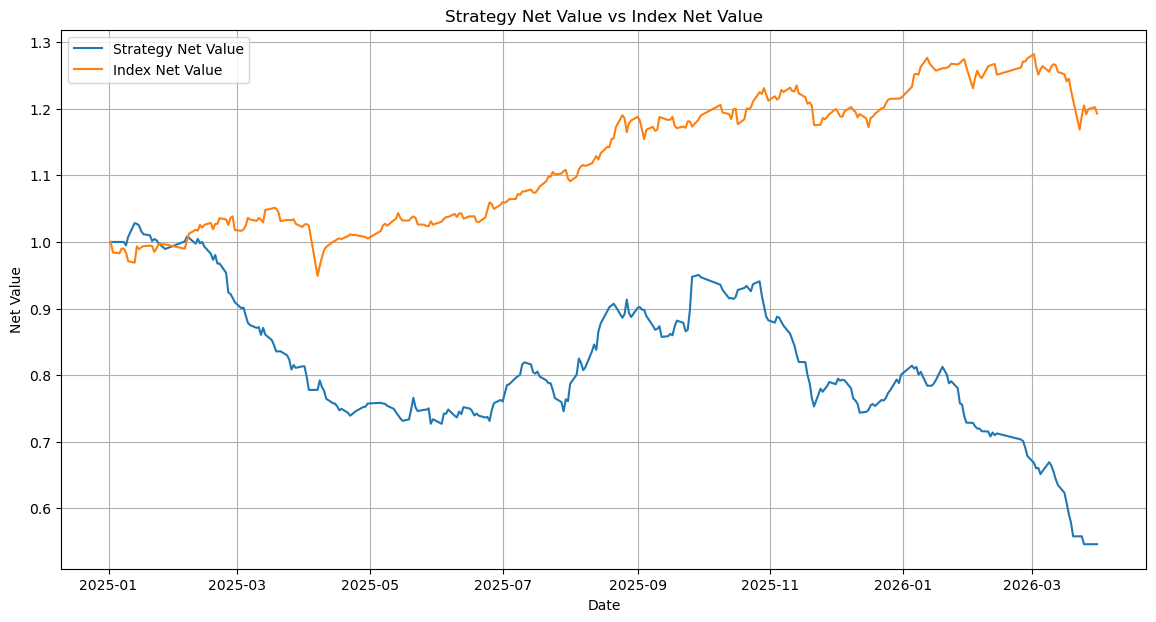

In [17]:
# ==================== 5. 回测结果分析 ====================

# 添加仓位权重（简单起见，每只股票等权重）
merged_df = merged_df.with_columns(
    pl.lit(0.4).alias("weight"),  # 单只股票最大仓位40%
    (pl.col("profit") * 0.4).alias("weight_profit")
)

# 统计卖出原因
if 'sell_reason' in merged_df.columns:
    logging.info("卖出原因统计:")
    reason_count = merged_df.group_by('sell_reason').agg(pl.count('code'))
    logging.info(reason_count)

# 生成回测报告
logging.info("=" * 50)
logging.info("双均线策略回测结果:")
back_result = report_backtest_full(
    merged_df.to_pandas(),
    start_date=start_date_str,
    end_date=end_date_str,
    profit_col='weight_profit'
)

In [18]:
# ==================== 6. 真实资金回测 ====================

from my_backtester.my_backtester import Backtester

交割数据 = merged_df.to_pandas()

# 构建orders
orders_list = []
for _, row in 交割数据.iterrows():
    if pd.isna(row['buy_time']) or pd.isna(row['sell_time']):
        continue
        
    buy_order = {
        "datetime": pd.to_datetime(row["buy_time"]),
        "code": row["code"],
        "direction": 1,
        "price": row["buy_price"],
        "cash_ratio": row["weight"],
        "buy_time": row["buy_time"],
        "sell_time": row["sell_time"],
    }
    sell_order = {
        "datetime": pd.to_datetime(row["sell_time"]),
        "code": row["code"],
        "direction": -1,
        "price": row["sell_price"],
        "cash_ratio": row["weight"],
        "buy_time": row["buy_time"],
        "sell_time": row["sell_time"],
    }
    orders_list.append(buy_order)
    orders_list.append(sell_order)

orders_df = pd.DataFrame(orders_list)

if len(orders_df) > 0:
    # 初始化回测引擎
    backtester = Backtester(
        orders=orders_df, 
        initial_cash=10000000, 
        commission=0.001, 
        slippage=0.001
    )
    
    # 运行回测
    资金结果 = backtester.run(start_time=start_date_str, end_time=end_date_str)
    持仓结果 = backtester.pos_log
    交易记录 = backtester.trade_log
    
    # 汇报回测结果
    metrics_df, fig = backtester.report(return_method="compound", plot=True)
    fig.show()
else:
    logging.info("没有足够的交易数据进行真实资金回测")

c:\Users\20561\Desktop\策略\my_backtester\my_backtester.py:585: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

资金不足,无法买入 SHSE.601825 405800 股，所需资金 3545656.69，当前现金 3542521.37
回测结果:
    指标名称                 指标值
  回测开始日期 2025-01-02 00:00:00
  回测结束日期 2026-03-31 00:00:00
    策略胜率              35.39%
   策略盈亏比                1.61
  策略总收益率             -11.26%
 策略年化收益率              -9.18%
    最大回撤             -17.11%
最大回撤开始日期 2025-08-26 00:00:00
最大回撤结束日期 2026-03-30 00:00:00
    夏普比率               -0.83
    最终净值              0.8874
